***Fase 1 - Preprocesamiento***

Objetivo
Preparar el dataset para el entrenamiento del MLP.


1. Importar librerias

In [914]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


2. Cargar dataset

In [915]:

ruta = "../data/DataSet_completo.xlsx"

df = pd.read_excel(ruta)

print("- Head")
print(df.head())
print("\n- Shape")
print(df.shape)
print("\n- Info")
print(df.info())


- Head
   SC_Media_Derecha  SC_Media_Izquierda  SC_Media_Horizontales  \
0        549.035330         -178.218490             -61.478745   
1         64.693783          698.281190             332.822770   
2       -886.648550          -92.229211              37.614070   
3        -63.286824         -134.380230               7.212969   
4         77.198319         -140.193090            -324.237390   

   SC_Varianza_Derecha  SC_Varianza_Izquierda  SC_Varianza_Horizontales  \
0         2.428328e+05           1.790635e+05              30059.288282   
1         4.196810e+05           1.210784e+06             387089.788130   
2         1.890156e+06           1.445906e+06              31956.846290   
3         3.909429e+05           4.501108e+05              21963.601301   
4         8.214648e+05           8.391239e+05              18449.489738   

   SC_Std_Derecha  SC_Std_Izquierda  SC_Std_Horizontales  SC_NoPicos_Derecha  \
0       492.78071         423.15893            173.37615         

3. Verificar valores nulos


In [916]:
print(df.isnull().sum())

#Si fuera el caso
df = df.dropna()

SC_Media_Derecha                    0
SC_Media_Izquierda                  0
SC_Media_Horizontales               0
SC_Varianza_Derecha                 0
SC_Varianza_Izquierda               0
SC_Varianza_Horizontales            0
SC_Std_Derecha                      0
SC_Std_Izquierda                    0
SC_Std_Horizontales                 0
SC_NoPicos_Derecha                  0
SC_NoPicos_Izquierda                0
SC_NoPicos_Horizontales             0
SC_DistanciaPicos_Derecha           0
SC_DistanciaPicos_Izquierda         0
SC_DistanciaPicos_Horizontales      0
SC_DifMaxMin_Derecha                0
SC_DifMaxMin_Izquierda              0
SC_DifMaxMin_Horizontales           0
Longitud                            0
SC_Multiplicacion_Media             0
SC_Multiplicacion_Varianza          0
SC_Multiplicacion_Std               0
SC_Multiplicacion_RMS               0
SC_Multiplicacion_NoPicos           0
SC_Multiplicacion_DistanciaPicos    0
SC_Suma_Media                       0
SC_Suma_Vari

4. Eliminar caractertíca dominante


In [917]:
#El proyecto exige eliminar "Longitud"
df.drop(columns=["Longitud"], inplace = True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SC_Media_Derecha                  200 non-null    float64
 1   SC_Media_Izquierda                200 non-null    float64
 2   SC_Media_Horizontales             200 non-null    float64
 3   SC_Varianza_Derecha               200 non-null    float64
 4   SC_Varianza_Izquierda             200 non-null    float64
 5   SC_Varianza_Horizontales          200 non-null    float64
 6   SC_Std_Derecha                    200 non-null    float64
 7   SC_Std_Izquierda                  200 non-null    float64
 8   SC_Std_Horizontales               200 non-null    float64
 9   SC_NoPicos_Derecha                200 non-null    int64  
 10  SC_NoPicos_Izquierda              200 non-null    int64  
 11  SC_NoPicos_Horizontales           200 non-null    int64  
 12  SC_Dista

5. Separar variables


In [918]:
X = df.drop(columns=["Clase"])
y = df["Clase"]

6. Estandarización


In [919]:
#Usaremos Z-Score con StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

7. Visualización inicial

- Distribución de clases

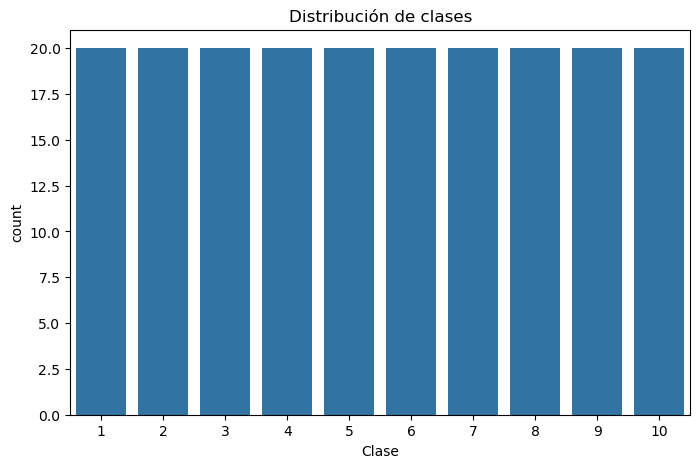

In [920]:
plt.figure(figsize=(8,5))
sns.countplot(x=y)
plt.title("Distribución de clases")
plt.show()

- Matriz de correlación inicial

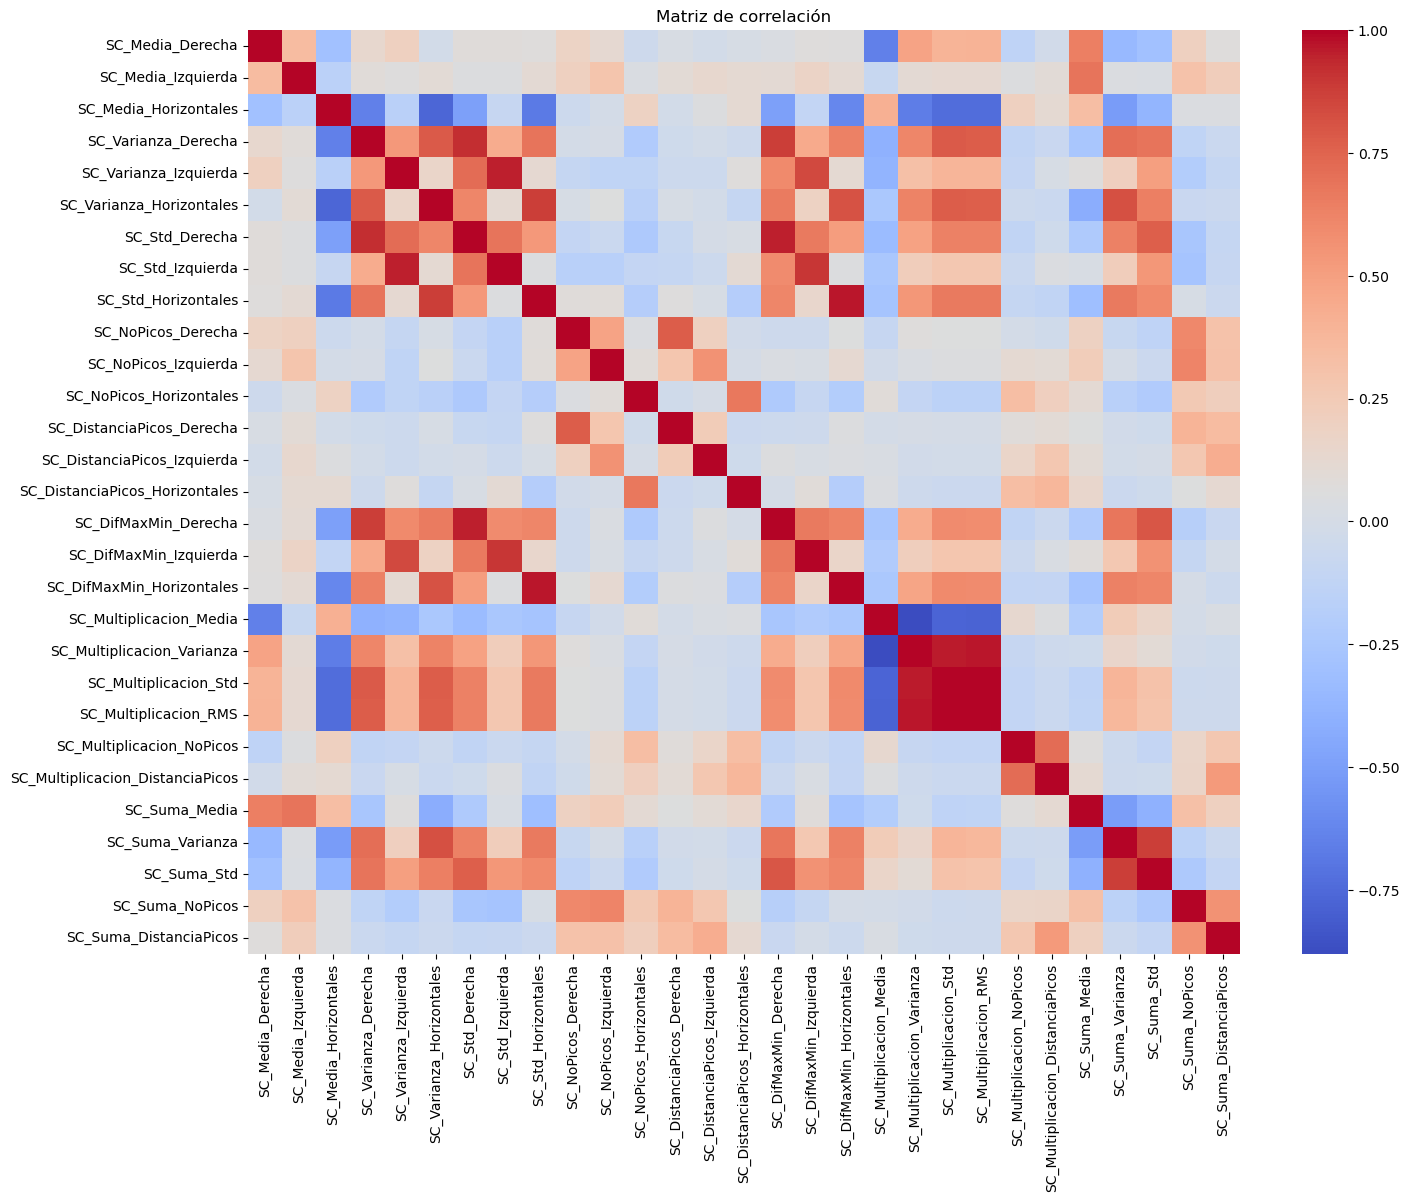

In [921]:
corr = X.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

***Fase 2 - Clasificación inicial con MLP***

Objetivo: Entrenar el primer modelo MLP usando TODAS las características excepto "Longitud".


1. División entrenamiento/prueba

In [922]:
#Usaremos estratificación porque son 10 clases
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

2. Crear modelo MLP

In [923]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    activation='tanh',
    solver='sgd',
    max_iter=300,
    random_state=42
)

3. Entrenar modelo

In [924]:
mlp.fit(X_train, y_train)

c:\Users\juana\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(100, ...)"
,activation,'tanh'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


4. Predicciones

In [925]:
y_pred = mlp.predict(X_test)

5. Metricas

In [926]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.525
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         4
           3       0.67      1.00      0.80         4
           4       0.50      0.75      0.60         4
           5       0.27      0.75      0.40         4
           6       0.57      1.00      0.73         4
           7       1.00      0.50      0.67         4
           8       1.00      0.50      0.67         4
           9       1.00      0.50      0.67         4
          10       0.50      0.25      0.33         4

    accuracy                           0.53        40
   macro avg       0.55      0.53      0.49        40
weighted avg       0.55      0.53      0.49        40



c:\Users\juana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\juana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\juana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


6. Matriz de confusión

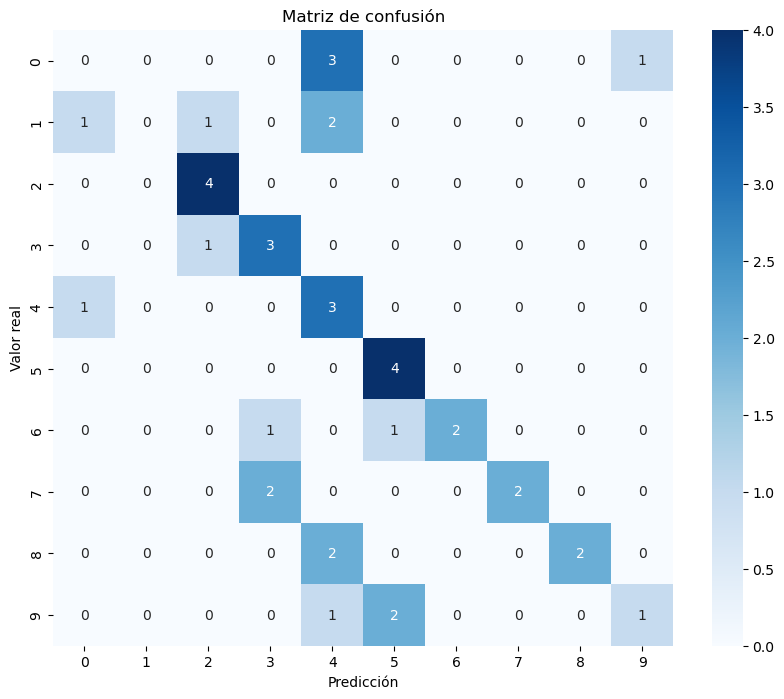

In [927]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

7. Curva de aprendizaje

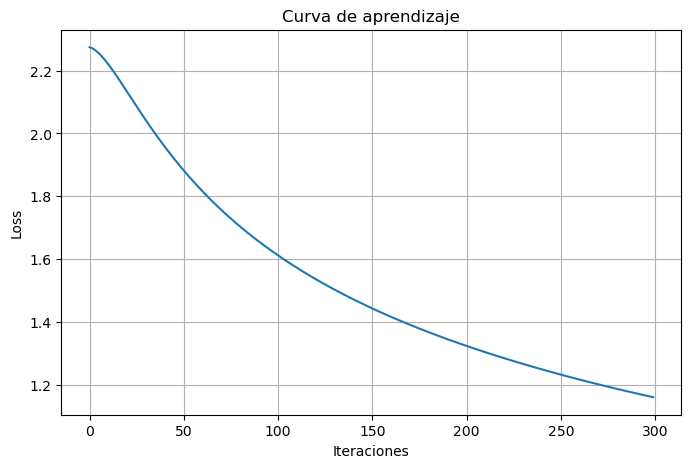

In [928]:
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Curva de aprendizaje")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

8. Probar hiperparámetros

    Probar varias configuraciones

* Arquitecturas

* Activaciones

* Solvers